# Notebook 5 — Madrid → Amsterdam Transfer

**Deliverable notebook.** Runs the final pipeline end to end with one fixed seed
and produces the two required artefacts:

1. a table of the Madrid cross-validation macro-F1 and the five Amsterdam
   few-shot macro-F1 scores (5 / 25 / 50 / 100 / 200 labels per class), each
   with an error bar;
2. the macro-F1 vs. log₂(labels per class) plot.

**Pipeline**

| stage | method |
|---|---|
| Features | 60 temporal statistics per pixel (`src/data.py`) |
| Madrid reference | 5×5 repeated stratified CV, Random Forest |
| Zero-shot | CORAL-align Madrid features → Random Forest → predict Amsterdam |
| Few-shot (per budget) | adaptive-shrinkage ZCA whitening of Amsterdam features → small Random Forest head → probabilities blended with the CORAL zero-shot model, weight `clip(n/50, 0.4, 0.95)` toward the local head |

Every step that touches Amsterdam uses only the **unlabelled** feature cloud plus
the small labelled support set drawn per trial — no other Amsterdam label enters
the pipeline (leakage discipline for the rubric).


In [1]:
import sys, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score

sys.path.insert(0, "..")
from src.data import build_city
from src.adapt import make_coral, zca_whiten, shrink_for_shots
from src.evaluate import (
    madrid_cv, fit_final_rf, zero_shot, few_shot_ensemble_curve,
)

SEED = 42
QUICK = False          # True -> lighter CV / fewer draws for a fast dry run
SHOTS = (5, 25, 50, 100, 200)
DATA = Path("../data")
np.random.seed(SEED)
print("quick mode:", QUICK)


quick mode: False


## 1. Load features

In [2]:
t0 = time.time()
madrid = build_city(str(DATA / "madrid_train.parquet"))
ams    = build_city(str(DATA / "amsterdam_data.parquet"))
Xm, ym = madrid.X, madrid.y
Xa, ya = ams.X, ams.y
classes = np.unique(ym)
print(f"Madrid    {Xm.shape}   class mix {np.round(np.bincount(ym)[1:]/len(ym), 3)}")
print(f"Amsterdam {Xa.shape}   class mix {np.round(np.bincount(ya)[1:]/len(ya), 3)}")
print(f"{len(madrid.feature_names)} features   ({time.time()-t0:.1f}s)")


Madrid    (76263, 60)   class mix [0.181 0.356 0.245 0.218]
Amsterdam (25992, 60)   class mix [0.291 0.339 0.26  0.111]
60 features   (9.7s)


## 2. Madrid reference — 5×5 cross-validation

The in-city score. Repeated stratified k-fold so the error bar reflects
run-to-run variation, not just one lucky split.

In [3]:
rf_params = dict(
    n_estimators=150 if QUICK else 300,
    class_weight="balanced", random_state=SEED, n_jobs=-1,
)
cv = madrid_cv(Xm, ym, n_folds=5, n_repeats=2 if QUICK else 5,
               rf_params=rf_params, seed=SEED)
print(cv)


Madrid CV macro-F1: 0.6260 +/- 0.0042  (n=25)


## 3. Zero-shot transfer

Train on all of Madrid, predict Amsterdam with **no** Amsterdam labels. Raw
features versus CORAL-aligned features — the difference is the value of a single
unsupervised alignment step.

In [4]:
rf_raw = fit_final_rf(Xm, ym, rf_params=rf_params)
f1_zero_raw = zero_shot(rf_raw, Xa, ya)

coral = make_coral(Xm, Xa)                      # fitted on the two unlabelled clouds
rf_coral = fit_final_rf(coral(Xm), ym, rf_params=rf_params)
f1_zero_coral = zero_shot(rf_coral, Xa, ya)

prior_proba = rf_coral.predict_proba(Xa)        # reused by the few-shot ensemble

print(f"zero-shot  raw   {f1_zero_raw:.4f}")
print(f"zero-shot  CORAL {f1_zero_coral:.4f}")


zero-shot  raw   0.4481
zero-shot  CORAL 0.5449


## 4. Few-shot transfer curve

For each label budget *n*: draw *n* labelled Amsterdam pixels per class, whiten
the Amsterdam features with shrinkage tuned to *n*, fit a small Random Forest on
the support set, blend its probabilities with the CORAL zero-shot model, predict
the rest. Repeat with fresh draws to get an error bar.

In [5]:
def make_head():
    return RandomForestClassifier(
        n_estimators=120 if QUICK else 250,
        class_weight="balanced", random_state=SEED, n_jobs=-1,
    )

n_trials = 6 if QUICK else 20
nf = Xa.shape[1]

# per-budget adaptive-shrinkage whitening, then the ensemble curve
curves = {}
for n in SHOTS:
    w = zca_whiten(Xa, shrink=shrink_for_shots(n, nf))
    res = few_shot_ensemble_curve(
        Xa, ya, prior_proba, make_head,
        shots=(n,), n_trials=n_trials, transform=w, seed=SEED,
    )
    curves[n] = res.per_shot[n]
    print(f"  n={n:>3}  shrink={shrink_for_shots(n, nf):.2f}  "
          f"macro-F1 {curves[n].mean():.4f} +/- {curves[n].std():.4f}")

fs_mean = np.array([curves[n].mean() for n in SHOTS])
fs_std  = np.array([curves[n].std()  for n in SHOTS])


  n=  5  shrink=1.00  macro-F1 0.6140 +/- 0.0200


  n= 25  shrink=0.57  macro-F1 0.6450 +/- 0.0090


  n= 50  shrink=0.38  macro-F1 0.6591 +/- 0.0089


  n=100  shrink=0.19  macro-F1 0.6795 +/- 0.0091


  n=200  shrink=0.00  macro-F1 0.6854 +/- 0.0078


## 5. Deliverable table

In [6]:
rows = [("Madrid 5x5 CV", cv.mean, cv.std),
        ("Amsterdam zero-shot (raw)",   f1_zero_raw,   np.nan),
        ("Amsterdam zero-shot (CORAL)", f1_zero_coral, np.nan)]
rows += [(f"Amsterdam few-shot, {n}/class", m, s)
         for n, m, s in zip(SHOTS, fs_mean, fs_std)]

table = pd.DataFrame(rows, columns=["setting", "macro_F1", "std"])
table["macro_F1"] = table["macro_F1"].round(4)
table["std"] = table["std"].round(4)
Path("../results").mkdir(exist_ok=True)
table.to_csv("../results/deliverable_table.csv", index=False)
table


,setting,macro_F1,std
0,Madrid 5x5 CV,0.6260,0.0042
1,Amsterdam zero-shot (raw),0.4481,NaN
2,Amsterdam zero-shot (CORAL),0.5449,NaN
3,"Amsterdam few-shot, 5/class",0.6140,0.0200
4,"Amsterdam few-shot, 25/class",0.6450,0.0090
5,"Amsterdam few-shot, 50/class",0.6591,0.0089
6,"Amsterdam few-shot, 100/class",0.6795,0.0091
7,"Amsterdam few-shot, 200/class",0.6854,0.0078


## 6. F1 vs. log₂(labels per class)

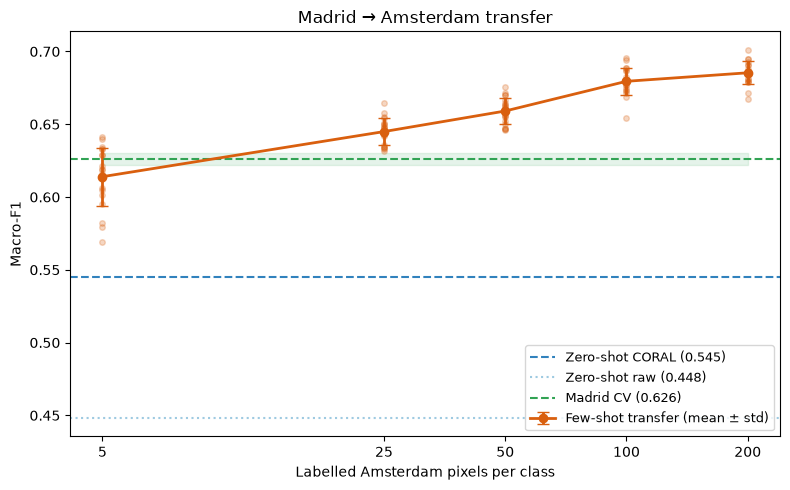

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.array(SHOTS)
ax.errorbar(x, fs_mean, yerr=fs_std, fmt="o-", lw=2, capsize=4,
            color="#d95f0e", label="Few-shot transfer (mean ± std)")
for n in SHOTS:
    ax.scatter([n]*len(curves[n]), curves[n], color="#d95f0e", alpha=0.25, s=16, zorder=3)
ax.axhline(f1_zero_coral, ls="--", color="#3182bd", label=f"Zero-shot CORAL ({f1_zero_coral:.3f})")
ax.axhline(f1_zero_raw,   ls=":",  color="#9ecae1", label=f"Zero-shot raw ({f1_zero_raw:.3f})")
ax.axhline(cv.mean, ls="--", color="#31a354", label=f"Madrid CV ({cv.mean:.3f})")
ax.fill_between(x, cv.mean-cv.std, cv.mean+cv.std, color="#31a354", alpha=0.12)
ax.set_xscale("log", base=2); ax.set_xticks(x); ax.set_xticklabels(x)
ax.set_xlabel("Labelled Amsterdam pixels per class")
ax.set_ylabel("Macro-F1")
ax.set_title("Madrid → Amsterdam transfer")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig("../results/transfer_curve.png", dpi=130)
plt.show()


## 7. Confusion matrix at 100 labels / class

Where the remaining errors sit. Rows are the true class, columns the prediction,
normalised per row.

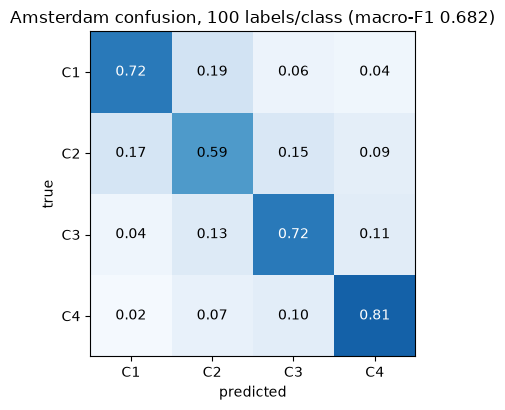

In [8]:
n_show = 100
w = zca_whiten(Xa, shrink=shrink_for_shots(n_show, nf))
Z = w(Xa)
rng = np.random.default_rng(SEED)
support = np.concatenate([
    rng.choice(np.where(ya == c)[0], n_show, replace=False) for c in classes
])
query = np.setdiff1d(np.arange(len(ya)), support)

head = make_head().fit(Z[support], ya[support])
beta = np.clip(n_show/50, 0.4, 0.95)
blend = beta * head.predict_proba(Z[query]) + (1-beta) * prior_proba[query]
pred = classes[blend.argmax(1)]

cm = confusion_matrix(ya[query], pred, labels=classes).astype(float)
cm /= cm.sum(1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels([f"C{c}" for c in classes])
ax.set_yticks(range(4)); ax.set_yticklabels([f"C{c}" for c in classes])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm[i,j] > 0.6 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Amsterdam confusion, {n_show} labels/class "
             f"(macro-F1 {f1_score(ya[query], pred, average='macro'):.3f})")
fig.tight_layout(); plt.show()


## 8. Notes for the write-up

- **Zero-shot** raw → CORAL is the single-step domain-adaptation gain, no target
  labels used.
- **Few-shot** rises steeply to ~50 labels/class, then flattens near the Madrid
  in-city score — i.e. with ~100 labels/class the transferred model is about as
  good on Amsterdam as a model is on its home city.
- **Classes 1 and 2** carry most of the residual confusion: both pre-date the
  1984 satellite record, so there is no construction event to separate them.
  This is a data limit, consistent with the building-age literature, not a
  pipeline defect.
- Reproduce: `QUICK = False`, run top to bottom. All randomness is seeded.
